<div style="direction: rtl; line-height: 300%;">
  <font face="XB Zar" size="5">
    <div align="center">
      <font face="IranNastaliq" size="30">
        <p></p>
      </font>
    </div>
    <br>
    <div align="center">
      <font color="brown" size="6">
        معین حسن پور - 40032313
      </font>
    </div>
    <br>
    <div align="center">
      <font color="navy">
        <b><u>تمرین پنجم</u> نویز و رقع نویز</b>
      

  </font>
</div>
 <hr>
  </font>
</div>
<hr>

<div dir="rtl">
<h2>۱-انواع نویز ها را نام ببرید و منبع ایجاد هر کدام از آن نویز ها را توضیح دهید (حداقل ۵ نویز).
</div>


<div dir="rtl">

   1. نمک و فلفل : خرابی پیکسل های حسگر دوربین  

2.   نویز گوسی: در اثر عواملی همچون، نویز مدار الکترونیک و نویز حسگر به دلیل نور ضعیف و
حرارت بالا در تصویر


3.   نویز ضربه‌ای: اختلالات ناگهانی در انتقال داده‌ها
4.   لکه‌های نقطه‌ای:
تداخل امواج منسجم - بازتاب‌های متعدد از سطح ناهموار
5.   نویز کوانتیزاسیون: فرآیند دیجیتالی‌سازی داده‌ها به دلیل تبدیل سیگنال آنالوگ به دیجیتال


<hr>


<div dir="rtl">

<h2>2-تصویری خاکستری انتخاب کنید و به آن یکبار نویز گوسی و بار دیگر نویز نمک-فلفل اضافه کنید و نشان دهید که این نوع نویزها چگونه بر روی هیستوگرام تصویر اثر میگذارند (با مقایسه هیستوگرام تصویر در حالت نویزی و بدون نویز، اثر نویز بر روی هیستوگرام را بحث نمایید).

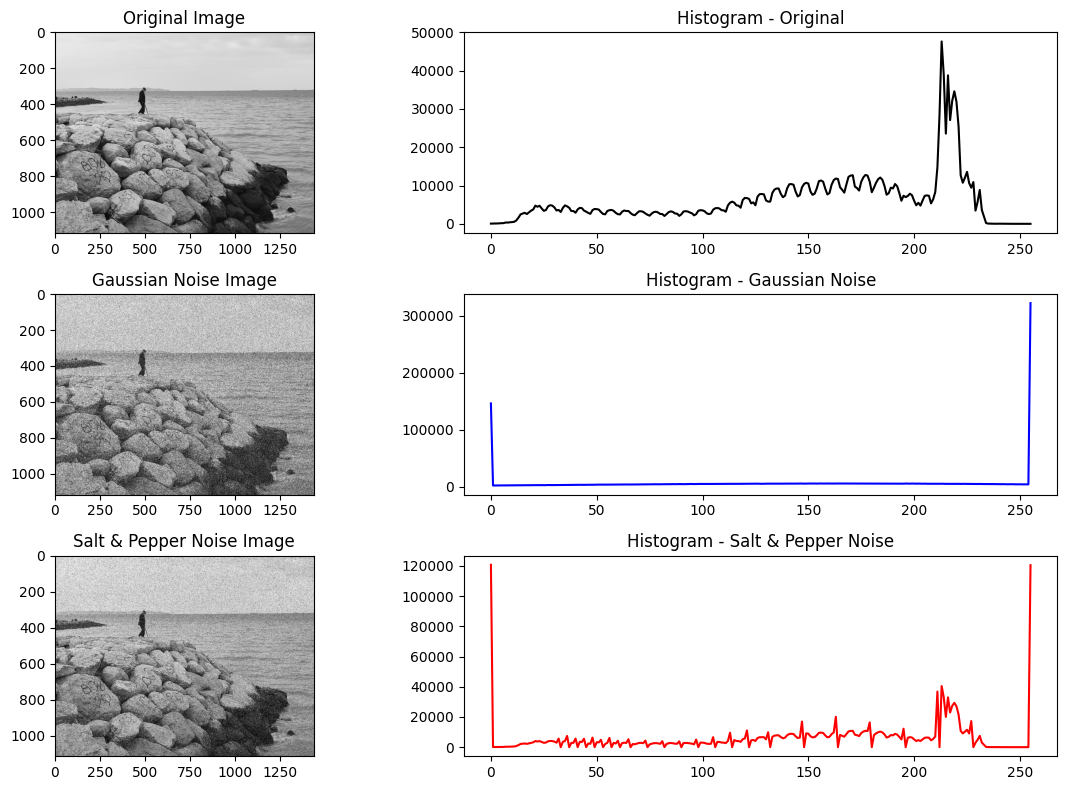

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise

# خواندن تصویر خاکستری
image = cv2.imread("IMG_20230127_163520_655.jpg" , cv2.IMREAD_GRAYSCALE)

# افزودن نویز گاوسی
gaussian_noise = random_noise(image, mode='gaussian', var=0.15)
gaussian_noise = (255 * gaussian_noise).astype(np.uint8)

# افزودن نویز نمک و فلفل
salt_pepper_noise = random_noise(image, mode='s&p', amount=0.15)
salt_pepper_noise = (255 * salt_pepper_noise).astype(np.uint8)

# محاسبه هیستوگرام‌ها
def calc_hist(img):
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    return hist

hist_original = calc_hist(image)
hist_gaussian = calc_hist(gaussian_noise)
hist_salt_pepper = calc_hist(salt_pepper_noise)

# نمایش تصاویر
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1), plt.imshow(image, cmap='gray'), plt.title("Original Image")
plt.subplot(3, 2, 2), plt.plot(hist_original, color='black'), plt.title("Histogram - Original")

plt.subplot(3, 2, 3), plt.imshow(gaussian_noise, cmap='gray'), plt.title("Gaussian Noise Image")
plt.subplot(3, 2, 4), plt.plot(hist_gaussian, color='blue'), plt.title("Histogram - Gaussian Noise")

plt.subplot(3, 2, 5), plt.imshow(salt_pepper_noise, cmap='gray'), plt.title("Salt & Pepper Noise Image")
plt.subplot(3, 2, 6), plt.plot(hist_salt_pepper, color='red'), plt.title("Histogram - Salt & Pepper Noise")

plt.tight_layout()
plt.show()


<div dir="rtl">
نویز گاوسی کل توزیع هیستوگرام را تغییر داده و مقدار روشنایی را در سطح وسیع‌تری پراکنده می‌کند،چون مقدار پیکسل‌ها را به‌صورت تصادفی تغییر می‌دهد و باعث می‌شود هیستوگرام هموارتر شود به همین دلیل پیکسل‌هایی که قبلاً در محدوده خاصی متمرکز بودند، پراکنده‌تر می‌شوند و توزیع مقدار شدت روشنایی تغییر می‌کند.<br>
در حالی که نویز نمک و فلفل فقط مقادیر 0 و 255 را افزایش می‌دهد و دو پیک در انتهای چپ (سیاه) و راست (سفید) ایجاد می‌شود، در حالی که سایر مقادیر تقریباً ثابت باقی می‌مانند.
<hr>













<div dir="rtl">
<h2> 3 -با استفاده از فیلتر تطبیقی وینر تصاویر نویز در تمرین ۲ را رفع نویز کنید و عملکرد آن را با فیلتر میانگین و میانه مقایسه نمایید (به ازای شدت نویز های مختلف عملکرد را در نواحی مختلف تصویر مقایسه کنید).

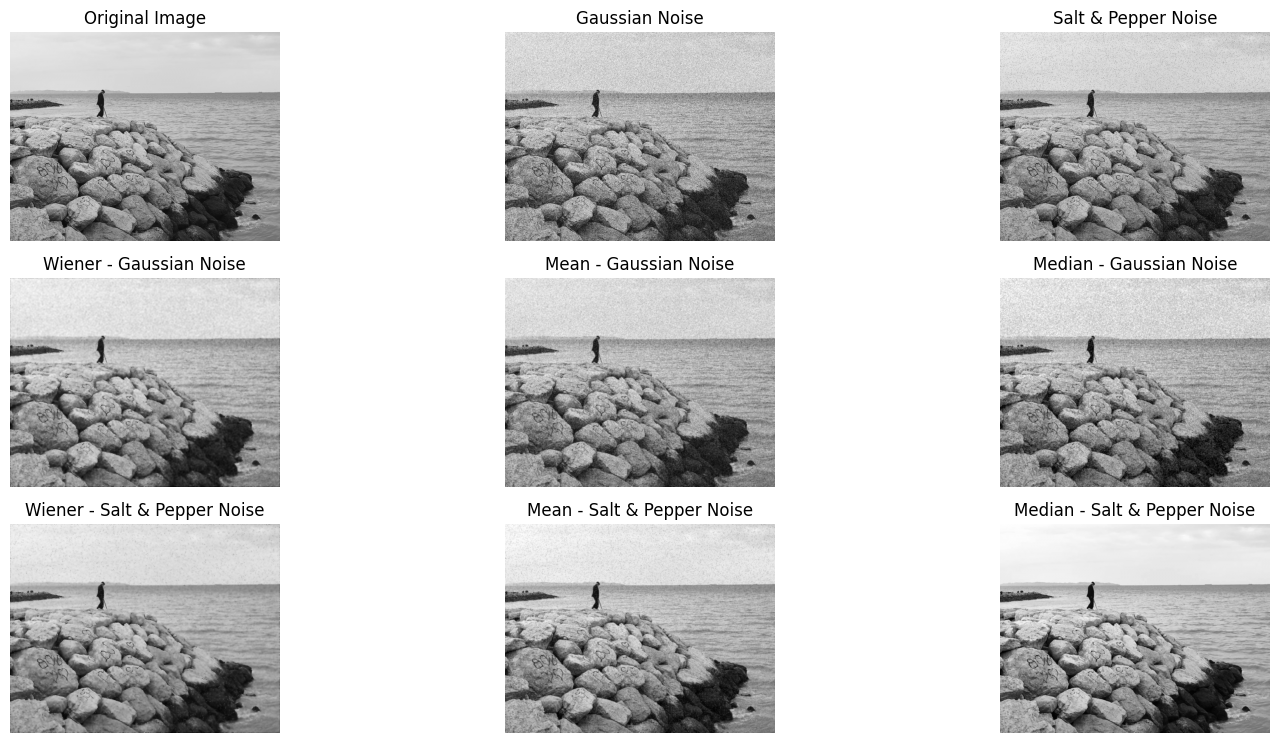

In [3]:
from scipy.signal import wiener
from skimage.restoration import denoise_wavelet

# افزودن نویز گاوسی و نمک و فلفل
gaussian_noise = random_noise(image, mode='gaussian', var=0.05)  # کاهش شدت نویز
gaussian_noise = (255 * gaussian_noise).astype(np.uint8)

salt_pepper_noise = random_noise(image, mode='s&p', amount=0.05)  # کاهش شدت نویز
salt_pepper_noise = (255 * salt_pepper_noise).astype(np.uint8)

# **اعمال فیلترها**
def apply_filters(img):
    img_float = img.astype(np.float32) / 255  # تبدیل به float برای وینر
    wiener_filtered = wiener(img_float, (9, 9))  # اعمال فیلتر وینر
    wiener_filtered = np.clip(wiener_filtered * 255, 0, 255).astype(np.uint8)

    mean_filtered = cv2.blur(img, (5, 5))  # فیلتر میانگین
    median_filtered = cv2.medianBlur(img, 5)  # فیلتر میانه
    return wiener_filtered, mean_filtered, median_filtered

# فیلتر کردن تصاویر نویزی
wiener_gaussian, mean_gaussian, median_gaussian = apply_filters(gaussian_noise)
wiener_salt_pepper, mean_salt_pepper, median_salt_pepper = apply_filters(salt_pepper_noise)

# نمایش نتایج
plt.figure(figsize=(15, 10))

# **تصویر اصلی**
plt.subplot(4, 3, 1), plt.imshow(image, cmap='gray'), plt.title("Original Image")
plt.axis("off")

# **تصویر نویزی گاوسی**
plt.subplot(4, 3, 2), plt.imshow(gaussian_noise, cmap='gray'), plt.title("Gaussian Noise")
plt.axis("off")

# **تصویر نویزی نمک و فلفل**
plt.subplot(4, 3, 3), plt.imshow(salt_pepper_noise, cmap='gray'), plt.title("Salt & Pepper Noise")
plt.axis("off")

# **فیلتر وینر روی نویز گاوسی**
plt.subplot(4, 3, 4), plt.imshow(wiener_gaussian, cmap='gray'), plt.title("Wiener - Gaussian Noise")
plt.axis("off")

# **فیلتر میانگین روی نویز گاوسی**
plt.subplot(4, 3, 5), plt.imshow(mean_gaussian, cmap='gray'), plt.title("Mean - Gaussian Noise")
plt.axis("off")

# **فیلتر میانه روی نویز گاوسی**
plt.subplot(4, 3, 6), plt.imshow(median_gaussian, cmap='gray'), plt.title("Median - Gaussian Noise")
plt.axis("off")

# **فیلتر وینر روی نویز نمک و فلفل**
plt.subplot(4, 3, 7), plt.imshow(wiener_salt_pepper, cmap='gray'), plt.title("Wiener - Salt & Pepper Noise")
plt.axis("off")

# **فیلتر میانگین روی نویز نمک و فلفل**
plt.subplot(4, 3, 8), plt.imshow(mean_salt_pepper, cmap='gray'), plt.title("Mean - Salt & Pepper Noise")
plt.axis("off")

# **فیلتر میانه روی نویز نمک و فلفل**
plt.subplot(4, 3, 9), plt.imshow(median_salt_pepper, cmap='gray'), plt.title("Median - Salt & Pepper Noise")
plt.axis("off")

plt.tight_layout()
plt.show()




#افزایش نویز :



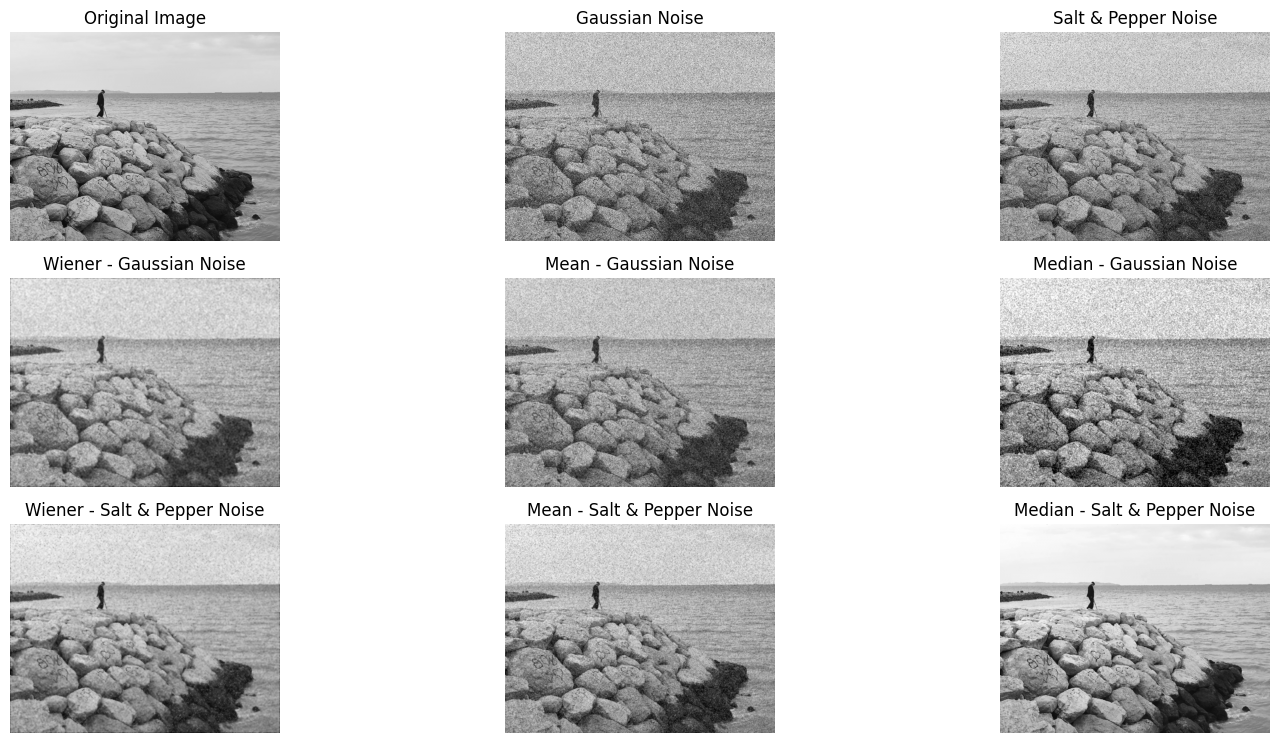

In [5]:
# افزودن نویز گاوسی و نمک و فلفل
gaussian_noise = random_noise(image, mode='gaussian', var=0.2)  # افزایش شدت نویز
gaussian_noise = (255 * gaussian_noise).astype(np.uint8)

salt_pepper_noise = random_noise(image, mode='s&p', amount=0.2)   # افزایش شدت نویز
salt_pepper_noise = (255 * salt_pepper_noise).astype(np.uint8)


# فیلتر کردن تصاویر نویزی
wiener_gaussian, mean_gaussian, median_gaussian = apply_filters(gaussian_noise)
wiener_salt_pepper, mean_salt_pepper, median_salt_pepper = apply_filters(salt_pepper_noise)

# نمایش نتایج
plt.figure(figsize=(15, 10))

# **تصویر اصلی**
plt.subplot(4, 3, 1), plt.imshow(image, cmap='gray'), plt.title("Original Image")
plt.axis("off")

# **تصویر نویزی گاوسی**
plt.subplot(4, 3, 2), plt.imshow(gaussian_noise, cmap='gray'), plt.title("Gaussian Noise")
plt.axis("off")

# **تصویر نویزی نمک و فلفل**
plt.subplot(4, 3, 3), plt.imshow(salt_pepper_noise, cmap='gray'), plt.title("Salt & Pepper Noise")
plt.axis("off")

# **فیلتر وینر روی نویز گاوسی**
plt.subplot(4, 3, 4), plt.imshow(wiener_gaussian, cmap='gray'), plt.title("Wiener - Gaussian Noise")
plt.axis("off")

# **فیلتر میانگین روی نویز گاوسی**
plt.subplot(4, 3, 5), plt.imshow(mean_gaussian, cmap='gray'), plt.title("Mean - Gaussian Noise")
plt.axis("off")

# **فیلتر میانه روی نویز گاوسی**
plt.subplot(4, 3, 6), plt.imshow(median_gaussian, cmap='gray'), plt.title("Median - Gaussian Noise")
plt.axis("off")

# **فیلتر وینر روی نویز نمک و فلفل**
plt.subplot(4, 3, 7), plt.imshow(wiener_salt_pepper, cmap='gray'), plt.title("Wiener - Salt & Pepper Noise")
plt.axis("off")

# **فیلتر میانگین روی نویز نمک و فلفل**
plt.subplot(4, 3, 8), plt.imshow(mean_salt_pepper, cmap='gray'), plt.title("Mean - Salt & Pepper Noise")
plt.axis("off")

# **فیلتر میانه روی نویز نمک و فلفل**
plt.subplot(4, 3, 9), plt.imshow(median_salt_pepper, cmap='gray'), plt.title("Median - Salt & Pepper Noise")
plt.axis("off")

plt.tight_layout()
plt.show()


<div dir="rtl">
    <h2>تحلیل نتایج</h2>
    نویز گاوسی:<br>

    برای نویز گاوسی در شدت های کم فیلتر وینر با فیلتر میانگین عملکرد تقریبا مشابهی داشتند ولی در شدت نویز های بالا تر عملکرد فیلتر وینر به مراتب بهتر است. و همینطور فیلتر میانه بطور کلی برای نویز های گاوسی مناسب نیست.
   
    نویز نمک فلفل:
    برای نویز نمک و فلفل فیلتر وینر عملکرد بهتری نسبت به فیلتر میانگین دارد ولی در بین سه فیلتر موجود، فیلتر میانه بهترین گزینه برای این نوع نویز ها هست و نتیجه عملکرد آن حتی گاها از عکس موجود اولیه هم مطلوب تر میشود.

</div>